# TD 2 - Régression polynomiale

Dans le TD précédent, nous avons construit "à la main" un modèle de régression linéaire :

$$
\hat y = wx + b
$$

Nous avons notamment vu :

- la fonction de prédiction
- la fonction de coût quadratique
- le calcul des gradients
- la descente de gradient
- l'importance de la standardisation

Dans ce TD, nous allons repartir de ces bases pour construire un modèle capable de représenter un problème **non linéaire**.

> **Rappel git** : N'oubliez pas de commit et push votre travail régulièrement !

## Préparation

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

## Exercice 1 - Observer une relation non linéaire

On étudie ici la consommation énergétique d'un véhicule en fonction de sa vitesse.

Imaginons que nous avons mesuré expérimentalement la consommation de carburant du véhicule pour différentes vitesses par tranche de 10 km/h. On veut à présent établir une fonction qui nous donnera la consommation pour n'importe quelle vitesse.

A faire dans le bloc de code ci-dessous :
1. Identifiez la variable d'entrée $X$ et la cible $y$.
2. Tracez les données.

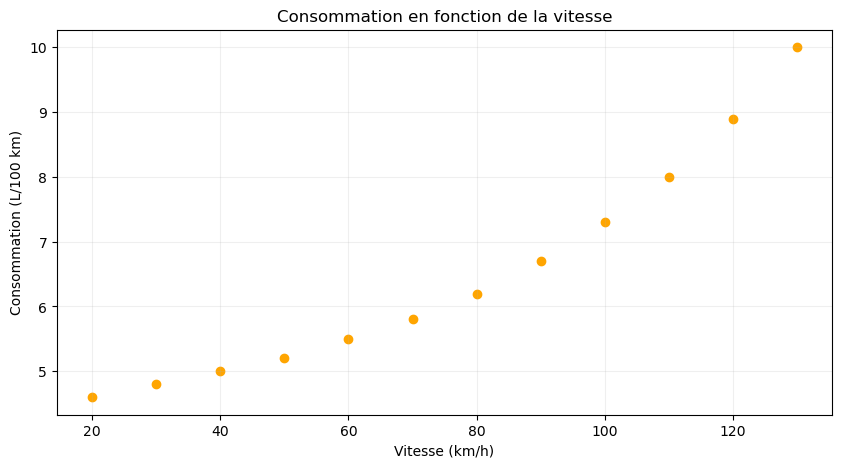

In [6]:
# Jeu de données expérimental
vitesse = np.array([20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130], dtype=float)
consommation = np.array([4.6, 4.8, 5.0, 5.2, 5.5, 5.8, 6.2, 6.7, 7.3, 8.0, 8.9, 10.0])

# À faire :
X = vitesse
y = consommation

plt.figure(figsize=(10, 5))

# À faire :
plt.scatter(X,y, c="orange")

plt.xlabel("Vitesse (km/h)")
plt.ylabel("Consommation (L/100 km)")
plt.title("Consommation en fonction de la vitesse")
plt.grid(alpha=0.2)
plt.show()

### Tester un modèle linéaire

On reprend la fonction de prédiction linéaire juste pour voir :

$$
\hat y = wx+b
$$

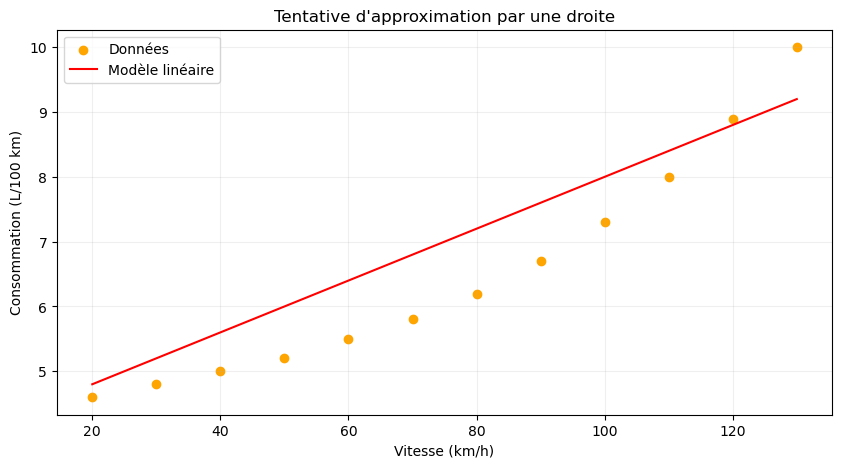

In [7]:
def predict_linear(X, w, b):
    return w * X + b

# Paramètres à l'oeil
w_test = 0.04
b_test = 4

pred_linear = predict_linear(X, w_test, b_test)

plt.figure(figsize=(10, 5))
plt.scatter(X, y, c="orange", label="Données")
plt.plot(X, pred_linear, c="red", label="Modèle linéaire")
plt.xlabel("Vitesse (km/h)")
plt.ylabel("Consommation (L/100 km)")
plt.title("Tentative d'approximation par une droite")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

Peu importe les valeurs de $w\_test$ et $b\_test$ que l'on choisit, on voit qu'une relation de la forme $wx+b$ n'est pas adaptée à ces données.
Nous allons donc améliorer le modèle en augmentant sa complexité.

### Question
1. Que se passerai-t-il si on faisait fonctionner notre algorithme du TD 1 avec ces données ?



## Exercice 3 - Ajouter un nouveau paramètre

Ajoutons un paramètre à notre modèle. Concrètement nous ajoutons un degré à notre fonction polynôme de degré 1 ($wx+b$).

On considère maintenant :

$$
\boxed{\hat y = w_1x+w_2x^2+b}
$$

Le modèle possède donc trois paramètres à apprendre :

- $w_1$ - poids associé à $x$
- $w_2$ - poids associé à $x^2$
- $b$ - biais

> Toutes les fonctions que nous allons implémenter à présent auront le sufixe $\_polynomial\_2$ pour indiquer qu'elles sont adaptées à un modèle de degré 2

Complétez le code de la fonction de prédiction suivante :

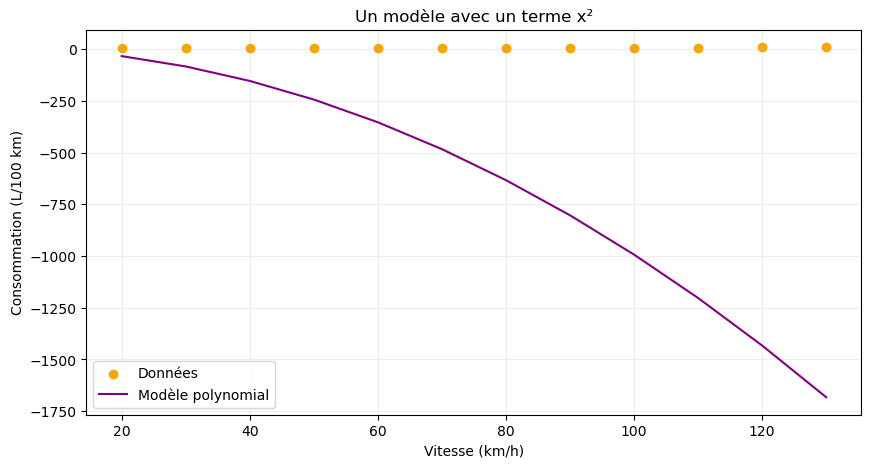

In [9]:
def predict_polynomial_2(X, w1, w2, b):
    '''
    cette fonction renvoie un polynôme de degré 2 échantilloné pour les valeurs de X
    '''
    # À faire :
    return (w1*(X**2))+(w2*X)+b

# Exemple arbitraire pour vérifier que la fonction produit bien une courbe
w1_test = -0.10
w2_test = 0.001
b_test = 7.0

pred_poly_test = predict_polynomial_2(X, w1_test, w2_test, b_test)

plt.figure(figsize=(10, 5))
plt.scatter(X, y, c="orange", label="Données")
plt.plot(X, pred_poly_test, c="purple", label="Modèle polynomial")
plt.xlabel("Vitesse (km/h)")
plt.ylabel("Consommation (L/100 km)")
plt.title("Un modèle avec un terme x²")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

Cette forme de courbe semble bien mieux adaptée à notre problème, il faut maintenant ajuster les paramètres.

Vous pouvez vous amuser à ajuster manuellement les paramètres du modèle pour approcher des données (comme dans le TD 1), mais n'y passez pas trop de temps, cela devient plus compliqué. On commence à voir l'intérêt d'utiliser la descente du gradient.

## Exercice 4 - Adapter la fonction de coût

On conserve exactement la même fonction de coût que dans le TD1 :

$$
J(w_1,w_2,b)
=
\frac{1}{2m}
\sum_{i=1}^{m}
(\hat y_i-y_i)^2
$$

La seule différence est la formule utilisée pour calculer $\hat y_i$.

### Question
1. Pourquoi la fonction de coût est elle quasiment identique à celle de pour notre modèle linéaire du TD 1 ?

Complétez `compute_loss_polynomial_2`.

In [29]:
def compute_loss_polynomial_2(X, y, w1, w2, b):
    '''
    Fonction de Loss quasiment identique à celle du modèle linéaire, à un petit détail près
    '''
    m = np.size(X)

    # À faire :
    predictions = predict_polynomial_2(X, w1, w2, b)
    squared_errors = (np.sum(predictions-y)**2)
    cost = (1/(2*m)) * squared_errors

    return cost


print("Loss du modèle de test :", compute_loss_polynomial_2(
    X, y, w1_test, w2_test, b_test
))

Loss du modèle de test : 2783315.150416666


## Exercice 5 - Calculer les nouveaux gradients

Pour le modèle :

$$
\hat y_i=w_1x_i+w_2x_i^2+b
$$

la fonction de coût est :

$$
J(w_1,w_2,b)=
\frac{1}{2m}
\sum_{i=1}^{m}
(\hat y_i-y_i)^2
$$


On utilisera l'expression de la dérivation d'une fonction composée $$(𝑔∘𝑢)'(𝑥)=𝑔'(𝑢(𝑥))⋅𝑢'(𝑥)$$ pour retrouver l'expression suivante valable pour n'importe quel paramètre $\theta$ :

$$
\frac{\partial J}{\partial \theta}
=
\frac{1}{m}
\sum_{i=1}^{m}
(\hat y_i-y_i)
\frac{\partial \hat y_i}{\partial \theta}
$$

#### 1. Dérivée par rapport à $w_1$

$$
\frac{\partial \hat y_i}{\partial w_1}=x_i
$$

donc :

$$
\boxed{
\frac{\partial J}{\partial w_1}
=
\frac{1}{m}
\sum_{i=1}^{m}
(\hat y_i-y_i)x_i
}
$$

#### 2. Dérivée par rapport à $w_2$

$$
\frac{\partial \hat y_i}{\partial w_2}=x_i^2
$$

donc :

$$
\boxed{
\frac{\partial J}{\partial w_2}
=
\frac{1}{m}
\sum_{i=1}^{m}
(\hat y_i-y_i)x_i^2
}
$$

#### 3. Dérivée par rapport à $b$

$$
\frac{\partial \hat y_i}{\partial b}=1
$$

donc :

$$
\boxed{
\frac{\partial J}{\partial b}
=
\frac{1}{m}
\sum_{i=1}^{m}
(\hat y_i-y_i)
}
$$

### Questions

1. Retrouvez sur papier les trois expressions ci-dessus.
2. Quelle différence observez-vous entre $dw_1$ et $dw_2$ ?
3. Pourquoi peut-on prévoir un problème d'échelle entre les deux gradients pour $x$ très grand ?

In [27]:
def compute_gradients_polynomial_2(X, y, w1, w2, b):
    m = np.size(X)

    # À faire :
    predictions = predict_polynomial_2(X, w1, w2, b)
    dist = predictions - y
    dw1 = w1 - dist
    dw2 = w2 - dist
    db = b - dist

    return dw1, dw2, db


dw1, dw2, db = compute_gradients_polynomial_2(X, y, 0, 0, 0)
print("dw1 :", dw1)
print("dw2 :", dw2)
print("db  :", db)

dw1 : [ 4.6  4.8  5.   5.2  5.5  5.8  6.2  6.7  7.3  8.   8.9 10. ]
dw2 : [ 4.6  4.8  5.   5.2  5.5  5.8  6.2  6.7  7.3  8.   8.9 10. ]
db  : [ 4.6  4.8  5.   5.2  5.5  5.8  6.2  6.7  7.3  8.   8.9 10. ]


## Exercice 6 - Première descente de gradient

La mise à jour des paramètres suit exactement le même principe que dans le TD1 :

$$
w_1 := w_1-\alpha\frac{\partial J}{\partial w_1}
$$

$$
w_2 := w_2-\alpha\frac{\partial J}{\partial w_2}
$$

$$
b := b-\alpha\frac{\partial J}{\partial b}
$$

Complétez la fonction suivante.

In [26]:
def gradient_descent_polynomial_2(
    X, y,
    w1=0, w2=0, b=0,
    alpha=1e-8,
    nb_iter=20000
):
    history = []

    for i in range(nb_iter):

        # À faire :
        dw1, dw2, db = compute_gradients_polynomial_2(X, y, w1, w2, b)
        w1 = w1 - alpha*dw1
        w2 = w2 - alpha*dw2
        b = b - alpha*db

        if i % 10 == 0:
            loss = compute_loss_polynomial_2(X, y, w1, w2, b)
            history.append((i, loss, w1, w2, b))

    return w1, w2, b, history


w1_raw, w2_raw, b_raw, history_raw = gradient_descent_polynomial_2(X, y)

print("w1 :", w1_raw)
print("w2 :", w2_raw)
print("b  :", b_raw)
print("loss finale :", history_raw[-1][1])

w1 : [-0.00095974 -0.00105508 -0.00118349 -0.00135665 -0.00162176 -0.00198618
 -0.00253979 -0.00339051 -0.00472516 -0.00687587 -0.01056914 -0.01710845]
w2 : [-0.00095974 -0.00105508 -0.00118349 -0.00135665 -0.00162176 -0.00198618
 -0.00253979 -0.00339051 -0.00472516 -0.00687587 -0.01056914 -0.01710845]
b  : [-0.00095974 -0.00105508 -0.00118349 -0.00135665 -0.00162176 -0.00198618
 -0.00253979 -0.00339051 -0.00472516 -0.00687587 -0.01056914 -0.01710845]
loss finale : 99136.85216155573


### Analyse

Nous ne prenons pas le temps ici d'afficher les résultats, car nous savons que le modèle ne peut pas encore bien converger. Il faut normaliser les entrées comme dans le TD précédent.

## Exercice 7 - Standardiser avant de construire les termes polynomiaux

On standardise d'abord $x$ :
$$
x_n=\frac{x-\mu}{\sigma}
$$
avec :

- $\mu$ : moyenne de x (mean)
- $\sigma$ : écart-type de x (std)

Cette stratégie permet d'éviter que la feature $x^2$ prenne des valeurs plusieurs milliers de fois plus grandes que la feature $x$.

In [23]:
x_mean = X.mean()
x_std = X.std()

# À faire :
X_norm = (X-x_mean)/x_std

print("Moyenne de X_norm :", X_norm.mean())
print("Écart-type de X_norm :", X_norm.std())
print("Valeurs de X_norm :", X_norm)

Moyenne de X_norm : 3.700743415417188e-17
Écart-type de X_norm : 1.0
Valeurs de X_norm : [-1.59325501 -1.30357228 -1.01388955 -0.72420682 -0.43452409 -0.14484136
  0.14484136  0.43452409  0.72420682  1.01388955  1.30357228  1.59325501]


In [30]:
# Nouvelle descente de gradient sur la variable standardisée
w1_norm, w2_norm, b_norm, history_norm = gradient_descent_polynomial_2(
    X_norm,
    y,
    w1=0,
    w2=0,
    b=0,
    alpha=0.01,
    nb_iter=1500
)

print("w1 standardisé :", w1_norm)
print("w2 standardisé :", w2_norm)
print("b standardisé  :", b_norm)
print("loss finale  :", history_norm[-1][1])

w1 standardisé : [-6.54307875e+06 -4.52411654e+03 -8.35033778e+01 -2.47374311e+01
 -2.18250052e+01 -3.95299624e+01 -4.11440604e+02 -1.20054069e+05
 -7.09481216e+08 -5.76266220e+13 -5.57006853e+19 -5.73338098e+26]
w2 standardisé : [-6.54307875e+06 -4.52411654e+03 -8.35033778e+01 -2.47374311e+01
 -2.18250052e+01 -3.95299624e+01 -4.11440604e+02 -1.20054069e+05
 -7.09481216e+08 -5.76266220e+13 -5.57006853e+19 -5.73338098e+26]
b standardisé  : [-6.54307875e+06 -4.52411654e+03 -8.35033778e+01 -2.47374311e+01
 -2.18250052e+01 -3.95299624e+01 -4.11440604e+02 -1.20054069e+05
 -7.09481216e+08 -5.76266220e+13 -5.57006853e+19 -5.73338098e+26]
loss finale  : 1.7403686764389823e+53


### Visualisation de la convergence

Complétez l'extraction des informations stockées dans `history_norm`.

Vérifiez que la loss et les paramètres se stabilisent.

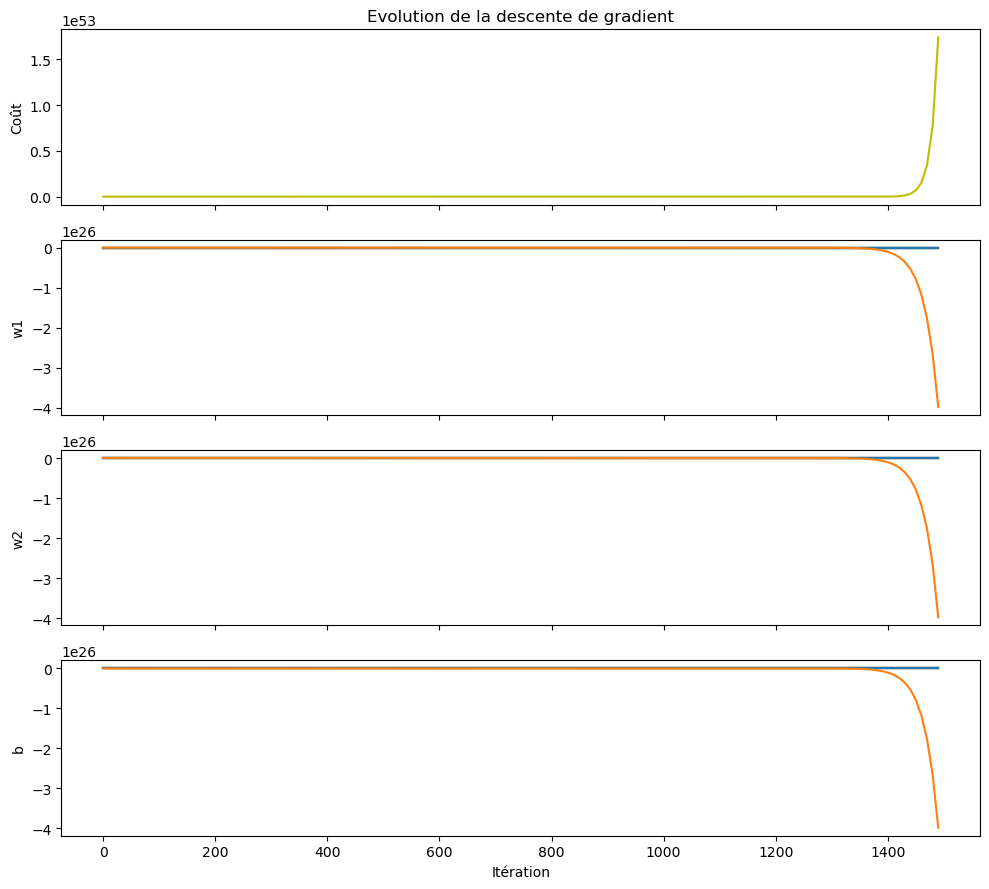

In [31]:
iterations = [h[0] for h in history_norm]

# À faire :
cost_history = [h[1] for h in history_norm]
w1_history = [h[2] for h in history_norm]
w2_history = [h[3] for h in history_norm]
b_history = [h[4] for h in history_norm]

fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)

axes[0].plot(iterations, cost_history, c="y")
axes[0].set_ylabel("Coût")
axes[0].set_title("Evolution de la descente de gradient")

axes[1].plot(iterations, w1_history)
axes[1].set_ylabel("w1")

axes[2].plot(iterations, w2_history)
axes[2].set_ylabel("w2")

axes[3].plot(iterations, b_history)
axes[3].set_ylabel("b")
axes[3].set_xlabel("Itération")

plt.tight_layout()
plt.show()

## Exercice 8 - Visualiser le modèle obtenu

Attention : le modèle a été entraîné avec $X_{norm}$.

Nous allons employer une méthode plus simple que dans le TD précédent pour retrouver des valeurs de sortie cohérente. 

Cette fois, nous allons appliquer la même opération mathématique aux données de test qu'à celles utilisées pour l'entraînement. 
on a fait la transformation suivante aux données d'entraînement :
$$
x_n=\frac{x-\mu}{\sigma}
$$

Nous devrons donc faire de même pour toutes les données d'entrée de notre modèle entraîné.
> **Attention** : on réutilise bien les mêmes valeurs de $\mu$ et $\sigma$ qui sont la moyenne et l'écart type **de l'ensemble d'entraînement**.

In [ ]:
x_plot = np.linspace(X.min(), X.max(), 300)

# À faire :
# standardiser les entrées du modèle
# x_plot_norm = ...
# effectuer les prédictions avec les valeurs standardisées
# y_plot = ...

plt.figure(figsize=(10, 5))
plt.scatter(X, y, c="orange", label="Données")
plt.plot(x_plot, y_plot, c="purple", label="Régression polynomiale")
plt.xlabel("Vitesse (km/h)")
plt.ylabel("Consommation (L/100 km)")
plt.title("Modèle polynomial entraîné par descente de gradient")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

Normalement, votre modèle devrait plutôt bien coller aux donnée. Sinon, essayez de trouver l'erreur dans votre code et demandez de l'aide si besoin.

### Questions

1. Le modèle passe-t-il exactement par tous les points ? Pourquoi ?
2. Est-ce souhaitable qu'un modèle passe nécessairement par tous les points d'entraînement ?

# Partie 2 - Généraliser à n'importe quel nombre de paramètres

Jusqu'ici, nous avons écrit séparément `w1` et `w2`.

Cette méthode devient vite peu pratique si on veut complexifier davantage le modèle :

$$
\hat y =
w_1x+
w_2x^2+
w_3x^3+
w_4x^4+
\dots+b
$$

Ca va vite devenir pénible d'ajouter de nouvelles variables $w_i$ à chaque fois que l'on souhaite élargir notre modèle. Il faut améliorer le code pour lui permettre de générer n'importe quel polynôme.

On va maintenant stocker tous les poids dans un seul vecteur :

$$
w=
\begin{bmatrix}
w_1\\
w_2\\
\vdots\\
w_n
\end{bmatrix}
$$

et toutes les features dans une matrice $X$.

L'idée est de revenir à l'expression mathématique du modèle linéaire que l'on connaît maintenant bien, mais avec des matrices.

$$
{\hat y=Xw+b}
$$


## Exercice 9 - Construire une matrice de features

Pour un polynôme de degré $n$, on veut transformer les entrée en une matrices dont les colonnes sont $[x,\ x^2,\ x^3,\ ... \ x^n]$

Ainsi, pour :
```text
X = [1, 2, 3]
```

on obtient :

```text
X_poly_2 =
[[1, 1],
 [2, 4],
 [3, 9]]

X_poly_3 =
[[1, 1, 1],
 [2, 4, 8],
 [3, 9, 27]]

 ... etc
```

Complétez la fonction suivante pour un degré quelconque.

> **Conseil** : Utilisez la fonction `np.column_stack` dont vous pouvez trouver la documentation en ligne.

In [ ]:
def polynomial_features(x, degree):
    # À faire :
    # return ...

test_X = np.array([1, 2, 3], dtype=float)
print("X_poly_2 =")
print(polynomial_features(test_X, degree=2))
print("\n X_poly_4 =")
print(polynomial_features(test_X, degree=4))

Si votre code est bon, le test donnera un résultat similaire à l'exemple du dessus.

## Exercice 10 - Prédiction vectorielle

Si une ligne de la matrice de features vaut :

$$
[x,\ x^2,\ x^3]
$$

et si :

$$
w=
[w_1,w_2,w_3]
$$

Pour toutes les observations à la fois, on peut écrire :

$$
\boxed{\hat y=Xw+b}
$$

La prédiction est alors :

$$
\hat y = w_1x+w_2x^2+w_3x^3+b
$$

En NumPy, le produit matriciel s'écrit avec `@`.

Vous pouvez donc réecrire une dernière fois l'expression de la prédiction en complétantnt le code suivant :

In [ ]:
def predict_polynomial(X, w, b):
    # À faire :
    # return ...


## Exercice 11 - Fonction de coût générique

La fonction de coût ne change pas :

$$
J(w,b)
=
\frac{1}{2m}
\sum_{i=1}^{m}
(\hat y_i-y_i)^2
$$

Cette fois, `w` est simplement un **vecteur** contenant autant de paramètres que nécessaire pour le degré visé.

Vous connaissez la suite ; ajustez la fonction suivante pour accepter un vecteur $w$ de taille libre.

In [ ]:
def compute_loss_polynomial(X, y, w, b):
    '''
    Comme d'habitude, mais w est un vecteur de paramètres du modèle
    '''
    m = len(y)

    # À faire :
    # y_hat = ...
    # dist = ...
    # return ...


## Exercice 12 - Gradient générique

On rappelle l'expression du gradient pour chaque paramètre $w_j$ :

$$
\frac{\partial J}{\partial w_j}
=
\frac{1}{m}
\sum_{i=1}^{m}
(\hat y_i-y_i)x_{i}^j
$$

(vous pouvez retrouver cette expression par récurrence à partir des calculs précédemment effectués pour le degré 2)

Toutes ces dérivées peuvent être regroupées en une seule expression matricielle :

$$
\boxed{
\nabla_w J
=
\frac{1}{m}X^T(\hat y-y)
}
$$

On peut s'affranchir de l'expression de la somme car il est déjà compris dans le calcul du produit matriciel (on rappelle que la matrice $X$ contient **toutes** les données d'entraînement).

et l'expression du gradient pour $b$ est toujours la même :

$$
\boxed{
\frac{\partial J}{\partial b}
=
\frac{1}{m}\sum_{i=1}^{m}(\hat y_i-y_i)
}
$$

Complétez la fonction.

In [ ]:
def compute_gradients_polynomial(X, y, w, b):
    '''
    renvoie un vecteur des gradients dw de chaque paramètres du vecteur w
    '''
    m = len(y)

    # À faire :
    # y_hat = ...
    # dist = ...
    # dw = ...
    # db = ...

    return dw, db

## Exercice 13 - Descente de gradient générique

Nous allons améliorer la fonction `gradient_descent_polynomial_2` pour qu'elle fonctionne avec n'importe quel degré de polynôme.

Le nombre de paramètres est déduit automatiquement du nombre de colonnes de `X`, qui correspond implicitement au degré du polynôme cible.

In [ ]:
def gradient_descent_polynomial(
    X, y,
    w=None,
    b=0,
    alpha=0.01,
    nb_iter=10000
):
    '''
    Cette fonction effectue une descente du gradient pour n'importe quel modèle polynomial
    w et dw sont maintenant des vecteurs, et X une matrice
    '''
    n = X.shape[1]

    if w is None:
        w = np.zeros(n)

    history = []

    for i in range(nb_iter):

        # À faire :
        # dw, db = ...
        # w = ...
        # b = ...

        if i % 50 == 0:
            history.append((
                i,
                compute_loss_polynomial(X, y, w, b),
                w.copy(),
                b
            ))

    return w, b, history

## Exercice 14 - Comparaison de notre nouveau modèle avec celui de degré 2

On a maintenant une procédure bien rodée :

- la standardisation des données du vecteur X
- la mise en forme de X avec `polynomial_features`
- la descente de gradient générique avec `compute_gradients_polynomial`

Complétez la construction de `X_poly` adapté à un modèle de degré 2.

En exécutant ce code de test, vous retrouvez normalement les mêmes paramètres finaux que précédemment.

In [ ]:
# Standardisation de la variable d'origine
X_norm = (X - X.mean()) / X.std()

# À faire :
# X_poly = ...

w, b, history = gradient_descent_polynomial(
    X_poly,
    y,
    alpha=0.01,
    nb_iter=10000
)

print("Poids :", w)
print("Biais :", b)
print("Loss finale :", history[-1][1])

## Exercice 15 - Faire varier le degré du polynôme

On va essayer différents degrés de polynômes entre 1 et 10.
Complétez le code dans la boucle ci-dessous pour entraîner 5 modèles de degrés croissant et les comparer.

> Pensez à réutiliser les variable **standardisées** que vous avez déjà calculées
> `X_norm` les données d'entraînement standardisées
> `x_plot_norm` les données de test formatées pour le modèle standardisé

Ne changez pas les valeurs de `alpha` et `nb_iter` pour l'instant

In [ ]:
# Liste des degrés de polynômes à tester
degrees = [1, 2, 3, 5, 10]

plt.figure(figsize=(10, 6))
plt.scatter(X, y, c="black", label="Données")

for degree in degrees:

    # À faire :
    # créer la matrice de données d'entraînement
    # X_poly = ...
    # appeler la descente du gradient générique
    w, b, history = gradient_descent_polynomial(
        X_poly,
        y,
        alpha=0.0005,
        nb_iter=60000
    )
    # À faire :
    # créer la matrice de données de test
    # X_plot_poly = ...
    # calculer les prédictions du modèle pour les données de test
    # y_plot = ...

   
    plt.plot(
        x_plot,
        y_plot,
        label=f"degré {degree}"
    )

    # affichage de la loss finale du modèle
    print(
        f"Degré {degree} - loss : "
        f"{history_degree[-1][1]:.5f}"
    )

plt.xlabel("Vitesse (km/h)")
plt.ylabel("Consommation (L/100 km)")
plt.title("Influence du degré du polynôme")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

### Questions
Pour chaque degré :

1. observez la courbe obtenue
2. relevez la loss
3. Quel est le meilleur modèle ? Ont ils tous convergé convenablement ?
4. Quels critères déterminent le "meilleur" modèle ?
5. La loss est elle un indicateur fiable ?

6. En regardant le graphe du degré 10, expliquer pourquoi un modèle très complexe peut devenir peu fiable sur de nouvelles données.
7. Quelle différence faites-vous entre :
   - bien représenter les données d'entraînement
   - bien généraliser à de nouvelles données
Pour vous aider, vous pouvez rechercher le terme "**overfitting**".

# "Exercice" 16 - Comparaison avec scikit-learn

`scikit-learn` peut générer automatiquement les termes polynomiaux grâce à `PolynomialFeatures`.

Pour une variable $x$ et un degré 2 :

```python
PolynomialFeatures(degree=2)
```

peut générer :

$$
1,\ x,\ x^2
$$

Ici, nous utilisons `include_bias=False`, car `LinearRegression` calcule déjà son propre biais.

In [ ]:
# Préparation des features avec scikit-learn
poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

X_sklearn = poly.fit_transform(
    X_norm.reshape(-1, 1)
)

model = LinearRegression()
model.fit(X_sklearn, y)

print("Coefficients sklearn :", model.coef_)
print("Biais sklearn :", model.intercept_)

# Comparaison avec notre implémentation générique
X_poly = polynomial_features(X_norm, degree=2)

w_manual, b_manual, history_manual = gradient_descent_polynomial(
    X_poly,
    y,
    alpha=0.01,
    nb_iter=20000
)

print("Coefficients manuels :", w_manual)
print("Biais manuel :", b_manual)

Si vous obtenez des résultats identiques, bravo ! Vous avez réussi.

## Bilan du TD

Nous sommes partis du modèle du TD1 :

$$
\hat y = wx+b
$$

puis nous avons ajouté une nouvelle feature :

$$
x^2
$$

pour obtenir :

$$
\hat y=w_1x+w_2x^2+b
$$

Enfin, nous avons généralisé l'écriture :

$$
\boxed{\hat y=Xw+b}
$$